## Celpose: Cell Segmenations

In [2]:
params = {'s1': [120, 219],
          's10': [99, 200],
          's11': [120, 219],
          's12': [140, 239],
          's14': [0, 100],
          }

495


Text(0.5, 1.0, '495')

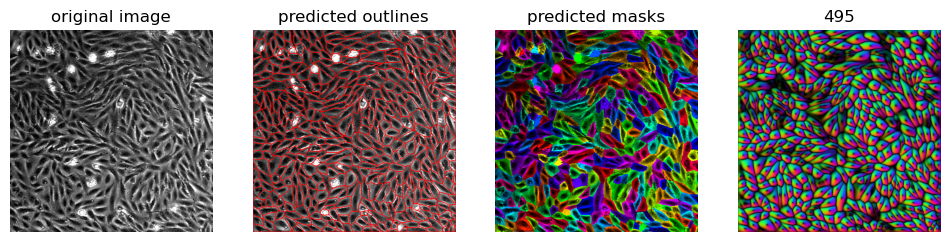

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io, plot, utils
from cellpose.io import imread
import os
from natsort import natsorted
import glob
from pathlib import Path
from joblib import Parallel, delayed
import sys
sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 


os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

%matplotlib inline
model = models.CellposeModel(gpu=True)

def predict_masks(image_path, flow_threshold=1,
                  cellprob_threshold=-.6, crop_box=-1, save_path=None):
    
    img = cv2.imread(image_path)[:crop_box, :crop_box, 0]
    masks, _, _ = model.eval(img,
                             flow_threshold=flow_threshold,
                             cellprob_threshold=cellprob_threshold)

    if save_path:
        save_path.mkdir(parents=True, exist_ok=True)
        save_mask = save_path / image_path.name
        cv2.imwrite(str(save_mask), masks)
        # print(save_mask)
    return masks

crop_box = 500

path = r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\RPE1_Fucci_C2C12_5x_15min_phase_nuclei_w1Trans_s1_t160.TIF"
img = cv2.imread(path)[:crop_box, :crop_box, 0]
masks, flows, _ = model.eval(img,
                            flow_threshold=1,
                            cellprob_threshold=-.6)

print(len(np.unique(masks)))

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img, masks, flows[0], channels=[0,0])
plt.title(len(np.unique(masks)))

Text(0.5, 1.0, '495')

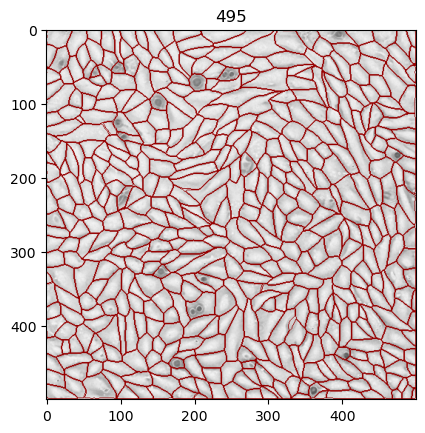

In [ ]:
%matplotlib inline
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img)

outX, outY = np.nonzero(utils.masks_to_outlines(masks))
img_rgb = cv2.cvtColor(255-img_clahe, cv2.COLOR_GRAY2RGB)

img_rgb[outX, outY] = np.array([150, 0, 0])  # pure red
plt.imshow(img_rgb)
plt.title(len(np.unique(masks)))

In [ ]:
# exp = 's1'
# base_path = Path(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei")
# save_path = Path(r"C:\Users\victo\My Drive\Curie\Trinish\Masks") / exp
# natsorted(base_path.glob(f"*{exp}*.TIF"), key=lambda y: y.name.lower())[120:219:1]
# glob.glob(str(save_path/(f"*{exp}*.TIF")))

In [ ]:
# model = models.CellposeModel(gpu=True)

exp = 's12'
base_path = Path(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei")
save_path = Path(r"C:\Users\victo\My Drive\Curie\Trinish\Masks") / exp

img_list = natsorted(base_path.glob(f"*{exp}*.TIF"), key=lambda y: y.name.lower())[146:params[exp][1]]

crop_box = 500
counts = [len(np.unique(predict_masks(p, #crop_box=crop_box,
                                     save_path=save_path)))
          for p in img_list]


### Correlations Density vs. ...
- Cell Count
- OP
- Number of defects
- Vrms

*Prepare tables from Raw an Masks*

In [4]:
params = {'s1': [120, 219],
          's10': [99, 200],
          's11': [120, 219],
          's12': [140, 239],
          's14': [0, 100],
          }

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from natsort import natsorted
import glob
from pathlib import Path
from joblib import Parallel, delayed
import sys
from cellpose import models, io, plot, utils
import seaborn as sns

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

exp = 's11'
save_path = Path(r"C:\Users\victo\My Drive\Curie\Trinish\Masks") / exp
mask_list = natsorted(save_path.glob(f"*{exp}_*"), key=lambda y: y.name.lower())

base_path = Path(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei")
img_list = natsorted(base_path.glob(f"*{exp}*.TIF"), key=lambda y: y.name.lower())[params[exp][0]:params[exp][1]]


NameError: name 'params' is not defined

In [20]:
mask_list[0], img_list[0], mask_list[-1], img_list[-1], len(mask_list), len(img_list)

(WindowsPath('C:/Users/victo/My Drive/Curie/Trinish/Masks/s10/RPE1_Fucci_C2C12_5x_15min_phase_nuclei_w1Trans_s10_t100.TIF'),
 WindowsPath('C:/Users/victo/My Drive/Curie/Trinish/30_01_18_RPE1_C2C12_5x_phase_nuclei/RPE1_Fucci_C2C12_5x_15min_phase_nuclei_w1Trans_s10_t100.TIF'),
 WindowsPath('C:/Users/victo/My Drive/Curie/Trinish/Masks/s10/RPE1_Fucci_C2C12_5x_15min_phase_nuclei_w1Trans_s10_t200.TIF'),
 WindowsPath('C:/Users/victo/My Drive/Curie/Trinish/30_01_18_RPE1_C2C12_5x_phase_nuclei/RPE1_Fucci_C2C12_5x_15min_phase_nuclei_w1Trans_s10_t200.TIF'),
 101,
 101)

In [14]:
counts = [(np.unique(cv2.imread(path, cv2.IMREAD_UNCHANGED))>0).sum() for path in mask_list]

In [10]:
450*1.5**2, 300*1.5**2,

(1012.5, 675.0)

In [27]:
%matplotlib qt

colors = sns.color_palette("Blues", len(mask_list[::10]))
    
bins = np.arange(0, 1500, 50)
for i, path in enumerate(mask_list[::10]):
    area = np.unique(cv2.imread(path, cv2.IMREAD_UNCHANGED),
                        return_counts=True)[-1][1:]
    area_ = area[area>80]*1.5**2
    sns.kdeplot(area_, fill=False, bw_adjust=.8, color=colors[i],
                label=(int(np.median(area_)), path.stem.split('_t')[-1][:3]))
plt.legend()
plt.xlabel('$Area ~(\mu m^2)$', fontsize=14)
plt.ylabel('$PDF$', fontsize=14)
plt.gca().set_box_aspect(1)
plt.xlim(0, 3000)
plt.title('$Cell ~Area$')

Text(0.5, 1.0, '$Cell ~Area$')

In [14]:
plt.ylabel('$PDF$', fontsize=14)

Text(79.1722222222222, 0.5, '$PDF$')

In [ ]:
crop_box = -1
ori_sigma = 25
ori_plus_min = Parallel(n_jobs=-1)(delayed(analyze_defects)(
    cv2.imread(path)[:crop_box,:crop_box,0], sigma=ori_sigma
    ) for path in img_list)

oris, plus, min = [], [], []
for q in ori_plus_min:
    oris.append(q[0])
    plus.append(q[1])
    min.append(q[2]) 

orders = np.array([order_parameter(ori, kernel_size=31) for ori in oris])

In [16]:
def uv_list(img1, img2, sigma=15, resize=None):
    '''Works for 8-bit and 16-bit images'''
    if img1.dtype != np.uint8:
        img1 = cv2.normalize(img1, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if img2.dtype != np.uint8:
        img2 = cv2.normalize(img2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if resize:
        img1 = cv2.resize(img1, (img1.shape[1]//resize, img1.shape[0]//resize), interpolation=cv2.INTER_AREA)
        img2 = cv2.resize(img2, (img2.shape[1]//resize, img2.shape[0]//resize), interpolation=cv2.INTER_AREA)
        
    flow = cv2.calcOpticalFlowFarneback(
        img1, img2, None, 0.5, 3, 
        winsize=sigma, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
    flow[..., 0] = flow[..., 0]- np.mean(flow[..., 0])
    flow[..., 1] = flow[..., 1]- np.mean(flow[..., 1])
    return flow[..., 0], flow[..., 1]

def compute_uv(image_list, sigma=15, resize=None):
    vel_list = Parallel(n_jobs=4)(delayed(uv_list)(
        cv2.imread(img1, cv2.IMREAD_GRAYSCALE),
        cv2.imread(img2, cv2.IMREAD_GRAYSCALE),
        sigma=sigma,
        resize=resize
        ) for (img1,img2) in zip(image_list[:-1], image_list[1:]))
    u = [vel[0] for vel in vel_list]
    v = [vel[1] for vel in vel_list]
    return u, v

resize = 1
u, v = compute_uv(img_list, sigma=7, resize=1)

fph = 4
px = 1.5 *resize
vrms = np.array([np.mean((uu**2 + vv**2)**.5) for (uu,vv) in zip(u,v)])

In [17]:
len(np.insert(vrms, 0, np.nan)), len([p.name for p in img_list]), len(mask_list)

(100, 100, 100)

In [18]:
df = pd.DataFrame({'image': [p.name for p in img_list], 
                   'count': counts,
                   'order': np.mean(orders, axis=(1,2)),
                   'plus': [len(p) for p in plus],
                   'min': [len(m) for m in min],
                   'vrms': np.insert(vrms, 0, np.nan)
                   })

df.to_csv(Path(r"C:\Users\victo\My Drive\Curie\Trinish") / f"{exp}_counts.csv", index=False)

In [19]:
%matplotlib qt
resize = 1
num = 50
step = 15//resize

fig, ax = plt.subplots()


ax.axis('off'); ax.axis('off')   
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

img1 = cv2.imread(img_list[num], cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(img_list[num+1], cv2.IMREAD_GRAYSCALE)
u,v = uv_list(img1, img2, sigma=step, resize=resize)

if resize !=1:
    img1 = cv2.resize(img1, (img1.shape[1]//resize, img1.shape[0]//resize), interpolation=cv2.INTER_AREA)
img_clahe = clahe.apply(img1)
# ax.imshow(255-img_clahe, cmap="gray")  

mask1 = cv2.imread(mask_list[num], cv2.IMREAD_UNCHANGED)
if resize !=1:
    mask1 = cv2.resize(mask1, (mask1.shape[1]//resize, mask1.shape[0]//resize), interpolation=cv2.INTER_AREA)

outX, outY = np.nonzero(utils.masks_to_outlines(mask1))
img_rgb = cv2.cvtColor(255-img_clahe, cv2.COLOR_GRAY2RGB)

img_rgb[outX, outY] = np.array([0, 150, 0])  # pure red
ax.imshow(img_rgb)
ax.set_title(img_list[num])


y, x = np.mgrid[0:img1.shape[0], 0:img1.shape[1]]

ax.quiver(x[::step, ::step], y[::step, ::step], 
    u[::step, ::step], -v[::step, ::step], 
    color="red", scale=80, alpha=.5, width=.005)

In [20]:
nn

NameError: name 'nn' is not defined

In [12]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from natsort import natsorted
import glob
from pathlib import Path
from joblib import Parallel, delayed
import sys
from cellpose import models, io, plot, utils
import seaborn as sns
sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

In [102]:
%matplotlib qt

path_list = natsorted(
    Path(r"C:\Users\victo\My Drive\Curie\Trinish").glob("*counts.csv")
)[1:-1]
colors = ['orange', 'green', 'red', 'purple','blue', ]

# fig, ax = plt.subplots(figsize=(4, 4))
dfs = []
for i, path in enumerate(path_list):
    df = pd.read_csv(path).dropna()
    df['count_rel'] = df['count'] / df['count'].iloc[0]
    df['op_rel'] = df['order'] / df['order'].iloc[0]
    df['rho_per_mm2'] = df['count'] / (1.5e-3* 2048)**2 #//20 *20# micron to mm
    df['charge'] = df['plus'] - df['min']
    df['defects'] = df['plus'] + df['min']

    dfs.append(df.reset_index())

# if you do want a “source” column you can do something like:
keys = [p.stem for p in path_list]
combined_df = pd.concat(dfs, keys=keys, names=['source']) \
                .reset_index(level='source').reset_index(drop=True)


x = 'rho_per_mm2'
categories = [
    # 'rho_per_mm2',
 'index',
 'count',
 'order',
 'plus',
 'min',
 'vrms',
 'count_rel',
 'op_rel',
 'charge',
 'defects'] #['order', 'op_rel', 'plus', 'min', 'charge', 'defects', 'vrms']
fig, axs = plt.subplots(1,len(categories), figsize=(len(categories)*3,3))
for i, y in enumerate(categories):
    plot_rolling_average(combined_df, axs[i], y,'rho_per_mm2',  win=10, avfunc=np.mean, stdfunc=np.std)
    axs[i].set_ylabel(y)
    axs[i].set_xlabel(r'$\rho ~(cells/mm^2)$') if x=='rho_per_mm2' else axs[i].set_xlabel(r'$frame$')

plt.tight_layout()
    

Text(0, 0.5, 'count')

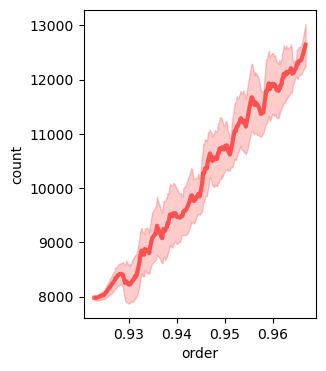

In [156]:
%matplotlib inline
x_category =  'order'#'op_rel' # 'order'
y_category = 'count'#'count_rel' # 'count'
win = 1e-3 # 100 # 0.004
fig, ax = plt.subplots(1,1, figsize=(3,4))
_ = plot_rolling_average(combined_df, ax, y_category, x_category,  win=win, avfunc=np.mean, stdfunc=np.std)
plt.xlabel(x_category); plt.ylabel(y_category)


In [29]:
with sns.axes_style('white'):
    sns.set_palette("tab10")
sns.pairplot(combined_df[['index', 'rho_per_mm2', 'count_rel', 'op_rel', 'plus', 'min', 'vrms','source']], hue='source', diag_kind='kde')
# sns.pairplot(combined_df[['rho_per_mm2', 'op_rel','defects', 'charge', 'vrms','source']], hue='source', diag_kind='kde')

slope = -0.000277 counts per step


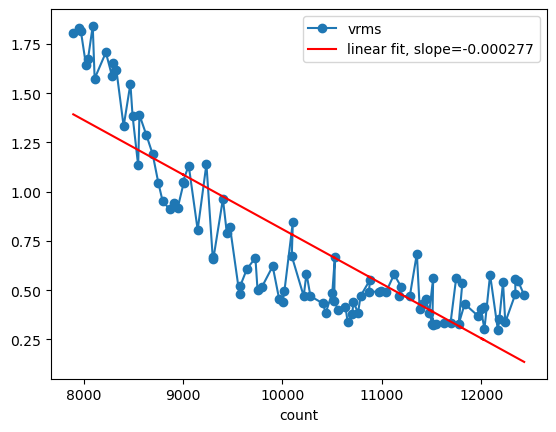

In [ ]:
col_name = 'vrms'  # replace with your column name
df_ = df.dropna()  # drop rows where the column is NaN

# build the abscissa and ordinate from the dataframe
# x = np.arange(len(df_))
x = df_['count'].values
y = df_[col_name].values

# linear fit of count versus row index
m, b = np.polyfit(x, y, 1)          # m is the slope, b the intercept
print(f"slope = {m:f} counts per step")

# optional: plot the data and the fitted line
ax = df_.plot(x='count', y=col_name, marker='o')
ax.plot(x, m*x + b, 'r-', label=f'linear fit, slope={m:f}')
ax.legend()

## NAPARI

In [1]:
params = {'s1': [120, 219],
          's10': [99, 200],
          's11': [120, 219],
          's12': [140, 239],
          's14': [0, 100],
          }

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from natsort import natsorted
import glob
from pathlib import Path
from joblib import Parallel, delayed
import sys
from cellpose import models, io, plot, utils
import napari
from skimage.measure import regionprops_table

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 


def density_inverse_area(mask, sigma=101):
    '''returns inverse area of cells as density map
    sigma is smoothing'''
    props = pd.DataFrame(regionprops_table(mask, properties=('label', 'area')))
    max_label = mask.max()
    area_lookup = np.zeros(max_label + 1)
    area_lookup[props['label']] = 1.0 / props['area']
    local_density_map = area_lookup[mask]
    smoothed_density = cv2.GaussianBlur(local_density_map, (sigma, sigma), 0)
    return smoothed_density

def track_table(masks):
    df = []
    for frame,mask in enumerate(masks):
        df_i = pd.DataFrame(regionprops_table(mask, properties=('label', 'centroid', 'area')))
        df_i['frame'] = frame
        df.append(df_i)

    return pd.concat(df)

In [3]:
exp = 's10'
save_path = Path(r"C:\Users\victo\My Drive\Curie\Trinish\Masks") / exp
mask_list = natsorted(save_path.glob(f"*{exp}_*"), key=lambda y: y.name.lower())

base_path = Path(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei")
img_list = natsorted(base_path.glob(f"*{exp}*.TIF"), key=lambda y: y.name.lower())[params[exp][0]:params[exp][1]]

df_path = glob.glob(r"C:\Users\victo\My Drive\Curie\Trinish\Nematics\*_"+exp+"_output*.csv")[0]
plus_minus_df = pd.read_csv(df_path).dropna(subset=["min_id","creation"])
minimal_track = 5
plus_minus_df = plus_minus_df.groupby('plus_id').filter(lambda x : len(x)>minimal_track).copy()

raws = np.array([cv2.imread(im, cv2.IMREAD_GRAYSCALE) for im in img_list])
masks = np.array([cv2.imread(im, cv2.IMREAD_UNCHANGED) for im in mask_list])
# densities = np.array([density_inverse_area(m) for m in masks])
densities = [density_inverse_area(m, sigma=51) for m in masks]
densities = np.array([d/d.mean() for d in densities])

In [ ]:
df_minus[['t','x', 'y', 'ang1','ang2','ang3','fuse_up']] = plus_minus_df[['FRAME','xm','ym','angm1','angm2','angm3','fuse_up']][plus_minus_df.fusion].copy()

In [ ]:
cells = pd.DataFrame()
cells[['frame','x','y','area']] = track_table(masks[:10])[['frame','centroid-0','centroid-1','area']].copy()

In [15]:
cells_ = tp.link_df(cells, 11, memory=1)

Frame 9: 8268 trajectories present.


In [16]:
cells_

,frame,x,y,area,particle
27,0,11.597015,1010.531343,335.0,0
26,0,6.774096,988.861446,332.0,1
25,0,8.855372,955.933884,242.0,2
24,0,6.536765,939.529412,136.0,3
23,0,8.113372,906.700581,344.0,4
...,...,...,...,...,...
8259,9,2041.495146,872.446602,103.0,7771
8265,9,2043.045455,696.393939,66.0,7802
8266,9,2043.511628,1679.290698,86.0,9565
8267,9,2043.155556,329.477778,90.0,9285


In [4]:
viewer = napari.Viewer()
viewer.add_image(raws[50:,:800,:800], name='Raws', colormap='gray', opacity=0.9)
viewer.add_labels(masks[50:,:800,:800], name='Masks', opacity=0.3)
viewer.add_image(densities[50:,:800,:800], name='Density', opacity=0.3, colormap='jet')

<Image layer 'Density' at 0x13abb37e3b0>

In [5]:
viewer = napari.Viewer()
viewer.add_image(raws, name='Raws', colormap='gray', opacity=0.9)
viewer.add_labels(masks, name='Masks', opacity=0.3)
viewer.add_image(densities, name='Density', opacity=0.3, colormap='jet')

<Image layer 'Density' at 0x13ab9362620>

In [12]:
viewer.add_image(densities, name='Density', opacity=0.3, colormap='jet')

<Image layer 'Density' at 0x13ae0f78670>

In [16]:
# densities = [density_inverse_area(m, sigma=51) for m in masks]
# d_densities = np.array([(d2-d1)/d2.mean() for d1,d2 in zip(densities[:-1], densities[1:])])
# viewer.add_image(d_densities, name='DNDensity', opacity=0.3, colormap='jet')

<Image layer 'DNDensity' at 0x13b896c8520>

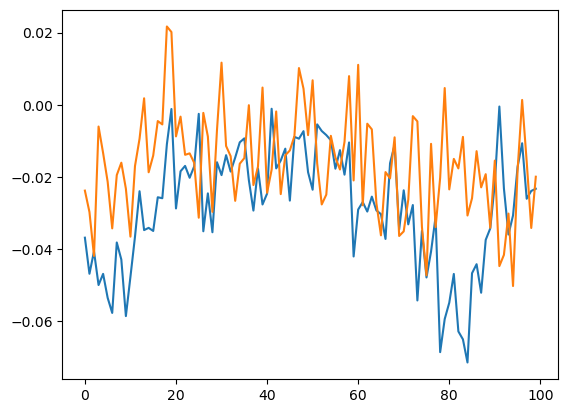

[INFO][2026/03/15 06:32:10 PM] Loading configuration file: C:\Users\victo\AppData\Local\btrack-examples\btrack-examples\Cache\examples\cell_config.json
[INFO][2026/03/15 06:32:10 PM] Loading configuration file: C:\Users\victo\AppData\Local\btrack-examples\btrack-examples\Cache\examples\particle_config.json


ERROR: No segmentation (Image layer) selected - cannot run tracking.


In [60]:
corr = []
corr_n = []
for op,d,dn in zip(orders, densities,d_densities):
    A = (1-op).flatten()
    B = np.abs(np.pad(d, (0,1), 'constant')).flatten()
    Bn = np.abs(np.pad(dn, (0,1), 'constant')).flatten()

    corr.append(np.corrcoef(A, B)[0, 1])
    corr_n.append(np.corrcoef(A, Bn)[0, 1])

    # break

plt.plot(corr)
plt.plot(corr_n)

In [51]:
np.pad(d, (0,1), 'constant').flatten().abs()

AttributeError: 'numpy.ndarray' object has no attribute 'abs'

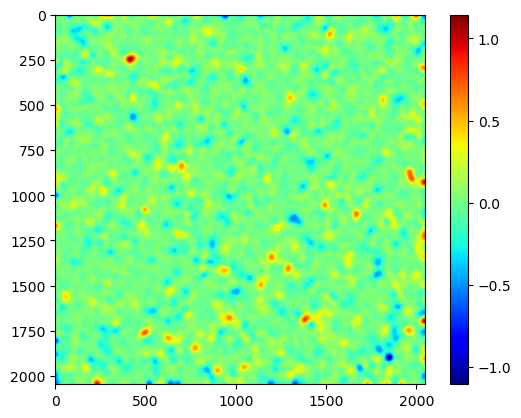

In [ ]:
c = plt.imshow(d_densities[0], cmap='jet')#, vmin=-1, vmax=1)
plt.colorbar()


In [6]:
ori_sigma = 31
ori_plus_min = Parallel(n_jobs=-1)(delayed(analyze_defects)(r, sigma=ori_sigma) for r in raws)
oris, plus, min = [], [], []
for q in ori_plus_min:
    oris.append(q[0])
    plus.append(q[1])
    min.append(q[2]) 


orders = np.array([order_parameter(ori, kernel_size=ori_sigma) for ori in oris])    

In [11]:
process_type = ['fusion', 'creation']
pcolor = ["#3d9bffff", "#ff4747ff"]
mcolor = ["#ff4747ff", "#ff4747ff"]
sigma = 21
opacity = .4

viewer = napari.Viewer()
viewer.add_image(raws, name='Raws', colormap='gray', opacity=0.9)
viewer.add_image(masks, name='Masks')
viewer.add_image(np.array(oris), name="Orientation map", opacity=0.6, colormap='hsv') 
viewer.add_image(orders, name="Oreder Parameter", opacity=0.6, colormap='ice') 

# for pcol,mcol,ptype in zip(pcolor, mcolor, process_type):
#     df_plus = pd.DataFrame()
#     df_minus = pd.DataFrame()

#     df_plus[['t','x','y','ang1','fuse_up']] = plus_minus_df[['FRAME','xp','yp','angp1','fuse_up']][plus_minus_df[ptype]].copy()
#     df_minus[['t','x', 'y', 'ang1','ang2','ang3','fuse_up']] = plus_minus_df[['FRAME','xm','ym','angm1','angm2','angm3','fuse_up']][plus_minus_df[ptype]].copy()

#     df_plus_ = df_plus[df_plus['t']<len(raws)].copy()
#     df_minus_ = df_minus[df_minus['t']<len(raws)].copy()

#     plus_data, plus_features = visualize_defects_from_table(df_plus_, ang='ang1')
#     pdefect = viewer.add_vectors(
#         plus_data, #features=plus_features,
#         edge_width=15, length=int(3*sigma),
#         edge_color=pcol, vector_style='triangle', opacity=opacity,
#         name='Plus',
#     )

    # for i in range(3):
    #     plus_data, plus_features = visualize_defects_from_table(df_minus_, ang='ang'+str(i+1))
    #     pdefect = viewer.add_vectors(
    #     plus_data, # features=plus_features,
    #     edge_width=15, length=int(3*sigma),
    #     edge_color=mcol, vector_style='triangle', opacity=opacity,
    #     name='Minus ang'+str(i+1),
        # )
    
#     # break

plus_data, plus_features = visualize_defects(plus, ang='ang1')
pdefect = viewer.add_vectors(
        plus_data, #features=plus_features,
        edge_width=10, length=int(5*sigma),
        edge_color="#e15252ff", vector_style='triangle', opacity=0.8,
        name='Plus_all',
)
for i in range(3):
    plus_data, plus_features = visualize_defects(min, ang='ang'+str(i+1))
    pdefect = viewer.add_vectors(
        plus_data, # features=plus_features,
        edge_width=10, length=int(5*sigma),
        edge_color="#3072dcff", vector_style='triangle', opacity=0.8,
        name='Minus ang'+str(i+1),
    ) 

viewer.add_vectors(
    visualize_ori(oris, step=int(1.2*sigma)), 
    edge_width=2., length=20, 
    edge_color="#fffb19ff", vector_style='line', opacity=.6,
    name='Orientation Field'
)

<Vectors layer 'Orientation Field' at 0x13addcf8b80>

In [168]:
viewer.add_image(
    np.array(oris),
    name="Orientation map",
    opacity=0.6,
    colormap='hsv'
) 

<Image layer 'Orientation map' at 0x2344df429e0>

In [ ]:
viewer.add_image(
    orders,
    name="Order Parameter",
    opacity=0.6,
    colormap='ice'
) 

<Image layer 'Oreder Parameter' at 0x23471ec6fb0>

In [ ]:
cc

In [9]:
for pcol,mcol,ptype in zip(pcolor, mcolor, process_type):
    df_plus = pd.DataFrame()
    df_minus = pd.DataFrame()

    df_plus[['t','x','y','ang1','fuse_up']] = plus_minus_df[['FRAME','xp','yp','angp1','fuse_up']][plus_minus_df[ptype]].copy()
    df_minus[['t','x', 'y', 'ang1','ang2','ang3','fuse_up']] = plus_minus_df[['FRAME','xm','ym','angm1','angm2','angm3','fuse_up']][plus_minus_df[ptype]].copy()

    df_plus_ = df_plus[df_plus['t']<len(raws)].copy()
    df_minus_ = df_minus[df_minus['t']<len(raws)].copy()

    plus_data, plus_features = visualize_defects_from_table(df_plus_, ang='ang1')
    pdefect = viewer.add_vectors(
        plus_data, #features=plus_features,
        edge_width=15, length=int(3*sigma),
        edge_color=pcol, vector_style='triangle',
        name='Plus',
    )

    for i in range(3):
        plus_data, plus_features = visualize_defects_from_table(df_minus_, ang='ang'+str(i+1))
        pdefect = viewer.add_vectors(
        plus_data, # features=plus_features,
        edge_width=15, length=int(3*sigma),
        edge_color=mcol, vector_style='triangle', opacity=1,
        name='Minus ang'+str(i+1),
        )
    
    # break

NameError: name 'visualize_defects_from_table' is not defined

In [ ]:
gg

NameError: name 'gg' is not defined

In [10]:
def flows_from_raws(img1, img2, winsize=15, smooth_sigma=None):
    if smooth_sigma is None:
        return cv2.calcOpticalFlowFarneback(img1, img2, None, 0.5, 3, winsize=winsize,
                                            iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
    else:
        flow = cv2.calcOpticalFlowFarneback(img1, img2, None, 0.5, 3, winsize=winsize,
                                            iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
        flow_sm = np.empty_like(flow)
        flow_sm[..., 0] = gaussian_filter(flow[..., 0], sigma=smooth_sigma)
        flow_sm[..., 1] = gaussian_filter(flow[..., 1], sigma=smooth_sigma)
        return flow_sm

def visualize_flow(flows, step=30):
    all_vecs = []
    # 2. Create (y, x) grid
    h, w = flows[0][::step, ::step].shape[:2]
    y, x = np.mgrid[0:h*step:step, 0:w*step:step]

    for t, flow in enumerate(flows):
        # 1. Downsample the grid
        sub_flow = flow[::step, ::step]
        
        # 3. Format coordinates: [t, y, x]
        # We add 't' so napari knows which frame the vector belongs to
        t_coords = np.full(y.size, t)
        pos = np.stack([t_coords, y.flatten(), x.flatten()], axis=1)
        
        # 4. Format displacements: [dt, dy, dx]
        # dt is 0 because the vector exists within a single frame
        dt = np.zeros(y.size)
        disp = np.stack([dt, sub_flow[..., 1].flatten(), sub_flow[..., 0].flatten()], axis=1)
        
        # 5. Stack into (N, 2, 3)
        frame_vecs = np.stack([pos, disp], axis=1)
        all_vecs.append(frame_vecs)   

    return np.concatenate(all_vecs, axis=0) 

def visualize_ori(oris, step=30):
    all_vecs = []
    # 2. Create (y, x) grid
    h, w = oris[0][::step, ::step].shape[:2]
    y, x = np.mgrid[0:h*step:step, 0:w*step:step]

    for t, ori in enumerate(oris):
        # 1. Downsample the grid
        sub_flow = ori[::step, ::step]
        
        # 3. Format coordinates: [t, y, x]
        # We add 't' so napari knows which frame the vector belongs to
        t_coords = np.full(y.size, t)
        pos = np.stack([t_coords, y.flatten(), x.flatten()], axis=1)
        
        # 4. Format displacements: [dt, dy, dx]
        # dt is 0 because the vector exists within a single frame
        dt = np.zeros(y.size)
        disp = np.stack([dt, -np.sin(sub_flow).flatten(), np.cos(sub_flow).flatten()], axis=1)
        
        # 5. Stack into (N, 2, 3)
        frame_vecs = np.stack([pos, disp], axis=1)
        all_vecs.append(frame_vecs)   

    return np.concatenate(all_vecs, axis=0) 


def visualize_ori_df(oris, step=30):
    all_frames = []
    
    # 1. Create (y, x) grid once (assuming all frames are same size)
    # Using oris[0].shape to ensure we cover the full image dimensions
    h, w = oris[0].shape
    y, x = np.mgrid[0:h:step, 0:w:step]

    for t, ori in enumerate(oris):
        sub = ori[::step, ::step]
        
        # 2. Build DataFrame for this frame
        # 'sub' is used for dy, dx, and the 'ori' property
        df = pd.DataFrame({
            't': t,
            'y': y.flatten(),
            'x': x.flatten(),
            'dt': 0,
            'dy': -np.sin(sub).flatten() * step, # Scaled for visibility
            'dx': np.cos(sub).flatten() * step,
            'orientation': sub.flatten()
        })
        all_frames.append(df)

    # 3. Consolidate into one DataFrame
    full_df = pd.concat(all_frames, ignore_index=True)

    # 4. Extract the (N, 2, 3) NumPy array required by napari
    # Format: [ [t, y, x], [dt, dy, dx] ]
    pos = full_df[['t', 'y', 'x']].values
    # disp = full_df[['dt', 'dy', 'dx']].values
    disp = full_df[['dt', 'dy', 'dx']].values
    vec_data = np.stack([pos, disp], axis=1)

    return vec_data, full_df

def visualize_defects(df_list, ang='ang1'):
    all_frames = []

    for t, p in enumerate(df_list):
        df = pd.DataFrame({
            't': t,
            'y': p['y'].values,
            'x': p['x'].values,
            'dt': 0,
            'dy': np.sin(p[ang]), # Scaled for visibility
            'dx': np.cos(p[ang]),
        })

        all_frames.append(df)

    # 3. Consolidate into one DataFrame
    full_df = pd.concat(all_frames, ignore_index=True)

    # 4. Extract the (N, 2, 3) NumPy array required by napari
    # Format: [ [t, y, x], [dt, dy, dx] ]
    pos = full_df[['t', 'y', 'x']].values
    disp = full_df[['dt', 'dy', 'dx']].values
    vec_data = np.stack([pos, disp], axis=1)

    return vec_data, full_df


def visualize_defects_from_table(df_all, ang='ang1'):
    df_all['dt'] = 0
    df_all['dy'] = np.sin(df_all[ang])
    df_all['dx'] = np.cos(df_all[ang])
    full_df = df_all.copy()

    # 4. Extract the (N, 2, 3) NumPy array required by napari
    # Format: [ [t, y, x], [dt, dy, dx] ]
    pos = full_df[['t', 'y', 'x']].values
    disp = full_df[['dt', 'dy', 'dx']].values
    vec_data = np.stack([pos, disp], axis=1)

    return vec_data, full_df


def flow_to_tracks(flow_series, step=40, iterations=None):
    """
    Converts a sequence of dense flow fields into trajectories.
    
    :param flow_series: List or array of shape (T, H, W, 2) where [..., 0] is dx and [..., 1] is dy
    :param step: N (integer). Seeds a track every N pixels.
    :param iterations: Number of frames to process.
    :return: Array of tracks with shape (Num_Tracks, T, 2)
    """
    T, H, W, _ = flow_series.shape
    iterations = iterations if iterations else T
    
    # 1. Initialize Seed Points (x, y) every N pixels
    yy, xx = np.mgrid[step//2:H:step, step//2:W:step]
    # ensure floating point positions to allow in-place addition of float displacements
    current_points = np.vstack([xx.ravel(), yy.ravel()]).T.astype(np.float64)
    
    # Initialize track storage: (Number of points, Time, 2) as float
    tracks = np.zeros((current_points.shape[0], iterations + 1, 2), dtype=np.float64)
    tracks[:, 0, :] = current_points
    
    # Define grid coordinates for interpolation
    grid_y = np.arange(H)
    grid_x = np.arange(W)

    # 2. Integrate Velocity Vectors
    for t in range(iterations):
        # Extract flow for the current frame
        flow_frame = flow_series[t]
        
        # Interpolate dx and dy at the current floating-point positions
        # Using 'linear' to handle points between pixels
        dx = interpn((grid_y, grid_x), flow_frame[..., 0], 
                     current_points[:, [1, 0]], method='linear', bounds_error=False, fill_value=0.0)
        dy = interpn((grid_y, grid_x), flow_frame[..., 1], 
                     current_points[:, [1, 0]], method='linear', bounds_error=False, fill_value=0.0)
        
        # 3. Update Positions: x_new = x + dx, y_new = y + dy
        current_points[:, 0] += dx
        current_points[:, 1] += dy
        
        # Store the updated position
        tracks[:, t + 1, :] = current_points

    
    
    n_tracks, n_timesteps, _ = tracks.shape
    track_ids = np.repeat(np.arange(n_tracks), n_timesteps)
    times = np.tile(np.arange(n_timesteps), n_tracks)
    coords = tracks.reshape(n_tracks * n_timesteps, 2)    
    
    
    return pd.DataFrame({
                        'track_id': track_ids,
                        't': times,
                        'x': coords[:, 0],
                        'y': coords[:, 1],
                        })

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, feature, filters
from scipy.spatial import distance

%matplotlib qt

def detect_mitosis_dog(frame_a_path, frame_b_path, min_sigma=15, max_sigma=65, threshold=0.1, search_radius=20):
    # 1. Load and Normalize Frames
    img_a = io.imread(frame_a_path, as_gray=True)
    img_b = io.imread(frame_b_path, as_gray=True)
    
    # Optional: Enhance local contrast
    img_a = (img_a - np.min(img_a)) / (np.max(img_a) - np.min(img_a))
    img_b = (img_b - np.min(img_b)) / (np.max(img_b) - np.min(img_b))

    # 2. Apply Difference of Gaussians (DoG) for Blob Detection
    # blobs_dog returns [y, x, sigma]
    blobs_a = feature.blob_dog(img_a, min_sigma=min_sigma, max_sigma=max_sigma, threshold=threshold)
    blobs_b = feature.blob_dog(img_b, min_sigma=min_sigma, max_sigma=max_sigma, threshold=threshold)

    mitotic_events = []

    # 3. Splitting Logic (1-to-2 transition)
    for parent in blobs_a:
        p_coord = parent[:2]
        
        # Find all candidates in Frame B within the search radius
        dists = distance.cdist([p_coord], blobs_b[:, :2])[0]
        potential_daughters = blobs_b[dists < search_radius]

        # A mitotic event is defined by exactly 2 daughters appearing near the parent
        if len(potential_daughters) == 2:
            d1, d2 = potential_daughters[0][:2], potential_daughters[1][:2]
            
            # Additional constraint: The parent should be roughly centered between daughters
            midpoint = (d1 + d2) / 2
            if distance.euclidean(p_coord, midpoint) < (search_radius / 2):
                mitotic_events.append({
                    'parent': p_coord,
                    'daughters': [d1, d2]
                })

    return img_a, img_b, mitotic_events

# --- Execution and Plotting ---
# Replace with your .tif or .png filenames
f_a = r"C:\Users\victo\OneDrive - BGU\DATA\C2C12 and RPE in 6 well\C2C12_RPE1_15min5x\_1\Pos22\img_channel000_position022_time000000015_z000.tif"
f_b = r"C:\Users\victo\OneDrive - BGU\DATA\C2C12 and RPE in 6 well\C2C12_RPE1_15min5x\_1\Pos22\img_channel000_position022_time000000016_z000.tif"

im_a, im_b, events = detect_mitosis_dog(f_a, f_b,
                                        search_radius=15,
                                        min_sigma=3, max_sigma=11,
                                        threshold=0.05)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor='white')
for ax, img, title in zip(axes, [im_a, im_b], ['Frame A (Before)', 'Frame B (After)']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

# Highlight Events
for ev in events:
    # Parent in Frame A (Cyan circle)
    axes[1].add_patch(plt.Circle((ev['parent'][1], ev['parent'][0]), 10, color='cyan', fill=False, lw=1))
    # Daughters in Frame B (Magenta circles)
    for d in ev['daughters']:
        axes[1].add_patch(plt.Circle((d[1], d[0]), 8, color='magenta', fill=False, lw=1))
        # Draw connection line
        axes[1].plot([ev['parent'][1], d[1]], [ev['parent'][0], d[0]], color='magenta', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Detected {len(events)} mitotic events.")

Detected 78 mitotic events.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, plot, utils
# from cellpose.io import imread
import os
from natsort import natsorted
import glob
from pathlib import Path
from joblib import Parallel, delayed
import sys